#Ensembles: Stacking - Heart Failure Prediction

In [4]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
import matplotlib.pyplot as plt
import seaborn as sns



# Load Datasets

In [30]:
df = pd.read_csv("/content/heart (1).csv")
#https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction?resource=download
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nTarget Distribution:")
print(df['HeartDisease'].value_counts())

Dataset shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Target Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


# EDA

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Statistical Summary:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


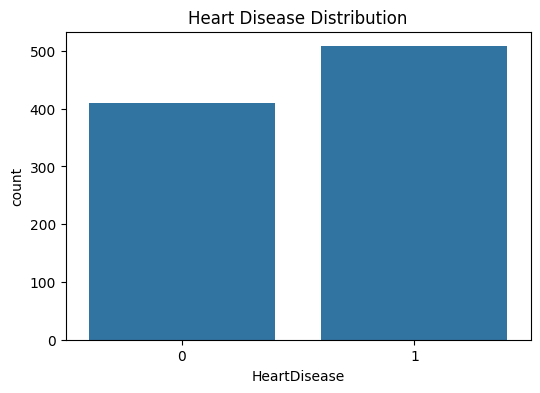

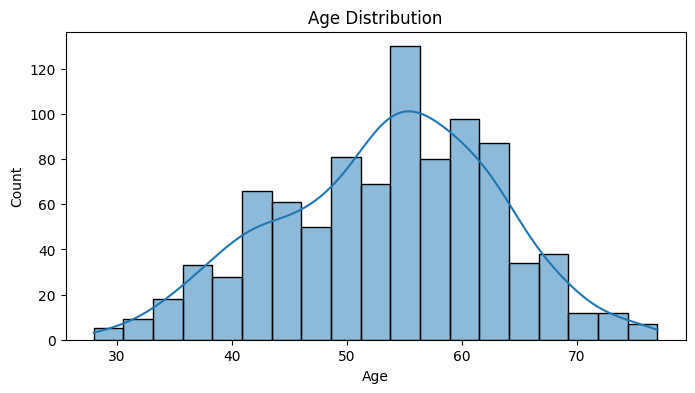


Correlation with target:
HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


In [19]:
print("Basic Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Heart Disease Distribution')
plt.show()

# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

# Correlation
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()['HeartDisease'].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr)

In [6]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [7]:
df.isin([0]).sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,1
Cholesterol,172
FastingBS,704
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,368


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


# Data Processing

In [26]:
# Quick sanity checks for your preprocessing

# 1. No missing values
assert X.isnull().sum().sum() == 0, "Missing values found!"
print("✅ No missing values")

# 2. Class balance
print(f"Original class distribution:\n{y.value_counts(normalize=True)}")
print(f"Train class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test class distribution:\n{y_test.value_counts(normalize=True)}")

# 3. Scaling check – train set should have ~0 mean and ~1 std
print(f"\nTrain mean (first 5 features): {X_train[:, :5].mean(axis=0)}")
print(f"Train std (first 5 features): {X_train[:, :5].std(axis=0)}")
# Test mean/std will not be exactly 0/1 (that's correct)
print(f"Test mean (first 5 features): {X_test[:, :5].mean(axis=0)}")

# 4. Dummy variable check – columns should be numeric (0/1 or scaled versions)
print(f"\nFeature dtype: {X.dtypes.unique()}")  # should be numeric
print(f"Number of features after encoding: {X.shape[1]}")

✅ No missing values
Original class distribution:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64
Train class distribution:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64
Test class distribution:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64

Train mean (first 5 features): [ 2.10549108e-16 -6.38907637e-16 -3.44864918e-17  1.45206281e-17
 -1.27055496e-16]
Train std (first 5 features): [1. 1. 1. 1. 1.]
Test mean (first 5 features): [-0.17868403 -0.13203054 -0.2039326   0.05026537  0.08348828]

Feature dtype: [dtype('int64') dtype('float64') dtype('bool')]
Number of features after encoding: 15


In [20]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)
print("Shape after encoding:", X.shape)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Preprocessing completed!")
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Shape after encoding: (918, 15)
✅ Preprocessing completed!
Train shape: (734, 15) | Test shape: (184, 15)


In [27]:
from sklearn.model_selection import StratifiedKFold

base_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Perceptron', Perceptron(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42))
]

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

meta_train = np.zeros((X_train.shape[0], len(base_models)))
meta_test = np.zeros((X_test.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models):
    print(f"Processing {name}...")
    fold_preds = np.zeros(X_train.shape[0])
    test_preds = np.zeros((n_folds, X_test.shape[0]))  # shape (folds, samples)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        clone = model.__class__(**model.get_params())
        clone.fit(X_train[train_idx], y_train.iloc[train_idx])

        if hasattr(clone, 'predict_proba'):
            # Logistic Regression, Decision Tree → use probability of class 1
            fold_preds[val_idx] = clone.predict_proba(X_train[val_idx])[:, 1]
            test_preds[fold, :] = clone.predict_proba(X_test)[:, 1]
        else:
            # Perceptron → use decision function (continuous score)
            fold_preds[val_idx] = clone.decision_function(X_train[val_idx])
            test_preds[fold, :] = clone.decision_function(X_test)

    meta_train[:, i] = fold_preds
    meta_test[:, i] = test_preds.mean(axis=0)  # average across folds

# Meta Model
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(meta_train, y_train)

print("✅ Stacking completed successfully!")

Processing Logistic Regression...
Processing Perceptron...
Processing Decision Tree...
✅ Stacking completed successfully!


In [28]:
print("="*60)
print("FINAL PERFORMANCE COMPARISON (AUC & F1-Score)")
print("="*60)

for name, model in base_models:
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        pred = (proba > 0.5).astype(int)
    else:
        # Perceptron – use decision_function for AUC
        pred = model.predict(X_test)
        proba = model.decision_function(X_test)

    auc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, pred)
    print(f"{name:22} | AUC: {auc:.4f} | F1: {f1:.4f}")

# Stacking Meta (unchanged)
meta_proba = meta_model.predict_proba(meta_test)[:, 1]
meta_pred = meta_model.predict(meta_test)
meta_auc = roc_auc_score(y_test, meta_proba)
meta_f1 = f1_score(y_test, meta_pred)

print(f"{'Stacking Meta-Model':22} | AUC: {meta_auc:.4f} | F1: {meta_f1:.4f}")

print("\n📊 Classification Report - Stacking Meta Model:")
print(classification_report(y_test, meta_pred))

FINAL PERFORMANCE COMPARISON (AUC & F1-Score)
Logistic Regression    | AUC: 0.9297 | F1: 0.9005
Perceptron             | AUC: 0.7635 | F1: 0.7511
Decision Tree          | AUC: 0.7813 | F1: 0.8152
Stacking Meta-Model    | AUC: 0.9353 | F1: 0.8920

📊 Classification Report - Stacking Meta Model:
              precision    recall  f1-score   support

           0       0.90      0.80      0.85        82
           1       0.86      0.93      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184




Final Results:
                 Model  Test_AUC  Test_F1
0  Logistic Regression    0.9297   0.9005
1           Perceptron    0.7635   0.7511
2        Decision Tree    0.7813   0.8152
3  Stacking Meta-Model    0.9353   0.8920


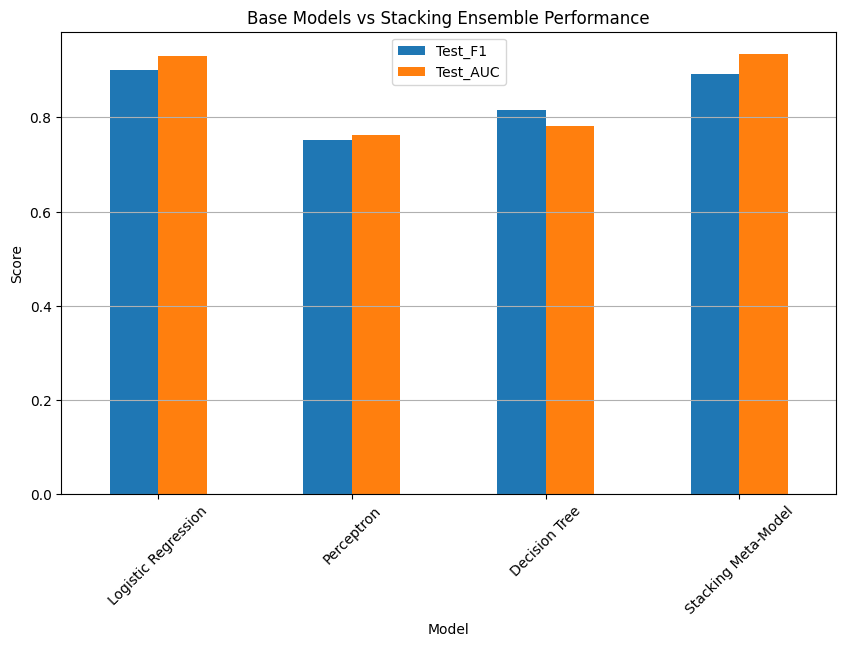

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

# Store results
results = {'Model': [], 'Test_AUC': [], 'Test_F1': []}

# Evaluate each base model (refit on full train, predict on test)
for name, model in base_models:
    model.fit(X_train, y_train)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        pred = (proba > 0.5).astype(int)
    else:  # Perceptron
        pred = model.predict(X_test)
        proba = model.decision_function(X_test)

    auc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, pred)
    results['Model'].append(name)
    results['Test_AUC'].append(auc)
    results['Test_F1'].append(f1)

# Stacking meta-model
meta_proba = meta_model.predict_proba(meta_test)[:, 1]
meta_pred = meta_model.predict(meta_test)
meta_auc = roc_auc_score(y_test, meta_proba)
meta_f1 = f1_score(y_test, meta_pred)
results['Model'].append('Stacking Meta-Model')
results['Test_AUC'].append(meta_auc)
results['Test_F1'].append(meta_f1)

# Final comparison table
res_df = pd.DataFrame(results)
print("\nFinal Results:")
print(res_df.round(4))

# Plot
res_df.plot(x='Model', y=['Test_F1', 'Test_AUC'], kind='bar', figsize=(10,6))
plt.title('Base Models vs Stacking Ensemble Performance')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

# What I Learned from the Results

Stacking improved the AUC, meaning it ranked predictions better, but F1 didn’t automatically go up  the default threshold still matters.


The ensemble got the highest AUC, so it successfully combined the strengths of all the base models.

A weak model like the Perceptron didn’t hurt the final result; the meta-model learned to rely less on it.

Using continuous scores (not just 0/1 labels) for AUC is crucial  with hard labels the Perceptron’s AUC looked terrible, but once I used decision scores it was more realistic.

The small but genuine improvement showed that cross‑validation was done right and there was no data leakage.

Overall, stacking is a practical way to get a bit more performance when the base models are different from each other, and you still need to tune the threshold if you’re focusing on F1.